# GVH Diagonal Cubic — RACC-C.4-real.2.14-V2
## GW150914 H1/L1 — Realistic Injection Estimator Qualification Audit V2
### Phase-sign fix • RAW-before-preprocessing injection • PSD-weighted SNR calibration

**Auteur :** Charlemagne O Laurince  
**Étape :** `RACC-C.4-real.2.14-V2`  
**Branche :** RACC-C.4 / GW150914 H1–L1  
**Noyau GVH Diagonal modifié : NON**

---

## Motivation

`real.2.14` a produit un verdict brut favorable aux estimateurs temporels, mais l'audit a révélé trois points à corriger avant toute qualification canonique :

1. **convention de signe de phase** : pour `scipy.signal.csd(a,b) = conj(A) B`, si
   \[
   b(t)=a(t-\tau),
   \]
   alors
   \[
   \phi_{ab}(f)\simeq -2\pi f\tau,
   \qquad
   \boxed{\tau=-\frac{1}{2\pi}\frac{d\phi}{df}} ;
   \]

2. **injection physique** : le signal doit être injecté dans le strain RAW, puis subir le **même prétraitement** que le bruit :
   \[
   x_{\rm analysed}=P[n_{\rm raw}+h_{\rm inj}] ;
   \]

3. **SNR réel** : `snr_scale` est remplacé par un SNR optimal pondéré par PSD :
   \[
   \rho^2 = 4\int_{f_{\min}}^{f_{\max}}
   \frac{|\tilde h(f)|^2}{S_n(f)}\,df .
   \]

---

## Question falsifiable

Le classement des estimateurs reste-t-il valide lorsque :

\[
\boxed{
\text{IMRPhenomD}
+
\text{bruit réel RAW H1/L1}
+
\text{retard connu}
+
\text{SNR réseau calibré}
}
\]

est analysé après un preprocessing identique pour bruit + signal ?

Estimateurs non-oracle :

- `xcorr`
- `GCC-PHAT`
- `phase_slope_unwrap`
- `phase_circular_2pi_safe`

Contrôle supérieur :

- `matched_template_oracle`

---

## Retards et SNR réseau

\[
\tau_{\rm inj}\in\{-10,-7,-4,-1,0,+1,+4,+7,+10\}\ {\rm ms}
\]

\[
\rho_{\rm network}\in\{8,12,20\}.
\]

---

## Gate de qualification

Pour un estimateur non-oracle :

\[
|\mathrm{median\ bias}|\le0.5\ {\rm ms},
\]

\[
\sigma_{\rm robust}=1.4826\,\mathrm{MAD}(e)\le1.5\ {\rm ms},
\]

\[
P(|e|\le2\,{\rm ms})\ge0.80,
\qquad
P_{90}(|e|)\le3\,{\rm ms}.
\]

Un garde-fou supplémentaire exige au SNR réseau le plus faible :

\[
P_{\rho=8}(|e|\le2\,{\rm ms})\ge0.60,
\qquad
P_{90,\rho=8}(|e|)\le5\,{\rm ms}.
\]

---

## Stop-rule

Même si un estimateur est qualifié :

\[
\boxed{
\texttt{TIMING-VALIDATED=False},
\quad
D_T^{ref}=\texttt{NOT-AUTHORIZED},
\quad
\texttt{REAL3-AUTHORIZED=False}
}
\]

Aucune modification de la chaîne HH, de `DISPERSION_READY` ou du noyau GVH.


In [1]:

import os, sys, subprocess, importlib, json, math, hashlib
from pathlib import Path

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import lal
    import lalsimulation as lalsim
    import lalframe
except Exception:
    pip_install("lalsuite")
    importlib.invalidate_caches()
    import lal
    import lalsimulation as lalsim
    import lalframe

try:
    import gwpy
except Exception:
    pip_install("gwpy")
    importlib.invalidate_caches()
    import gwpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from gwpy.timeseries import TimeSeries

RNG = np.random.default_rng(21402)

print("gwpy:", gwpy.__version__)
print("lalsimulation:", hasattr(lalsim, "SimInspiralChooseFDWaveform"))


/tmp/ipykernel_862/1334303434.py:14: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


gwpy: 4.0.1
lalsimulation: True


## 1 — Chargement H1/L1

In [2]:

GPS_EVENT = 1126259462.0
FS_EXPECTED = 4096.0

def discover(pattern):
    roots = [Path.cwd(), Path("/content"), Path("/content/drive/MyDrive"), Path("/mnt/data")]
    hits = []
    for root in roots:
        if not root.exists():
            continue
        for d in [root, root/"data"/"GW150914", root/"gvh_diagonal_cubic"/"data"/"GW150914"]:
            if d.exists():
                hits += list(d.glob(pattern))
    return hits[0].resolve() if hits else None

H1 = discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
L1 = discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")

if H1 is None or L1 is None:
    try:
        from google.colab import files
        files.upload()
        H1 = discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
        L1 = discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")
    except Exception:
        pass

if H1 is None or L1 is None:
    raise FileNotFoundError("Fichiers H1/L1 GW150914 introuvables.")

h1_ts = TimeSeries.read(str(H1), channel="H1:LOSC-STRAIN")
l1_ts = TimeSeries.read(str(L1), channel="L1:LOSC-STRAIN")

h1 = np.asarray(h1_ts.value, float)
l1 = np.asarray(l1_ts.value, float)
fs = float(h1_ts.sample_rate.value)
gps0 = float(h1_ts.t0.value)
t_rel = gps0 + np.arange(len(h1))/fs - GPS_EVENT

assert np.isclose(fs, FS_EXPECTED)
assert len(h1) == len(l1) == 131072
assert np.isfinite(h1).all() and np.isfinite(l1).all()

print(H1.name)
print(L1.name)
print("N =", len(h1), "fs =", fs)


Saving L-L1_LOSC_4_V2-1126259446-32.gwf to L-L1_LOSC_4_V2-1126259446-32.gwf
Saving H-H1_LOSC_4_V2-1126259446-32 2.gwf to H-H1_LOSC_4_V2-1126259446-32 2.gwf
H-H1_LOSC_4_V2-1126259446-32 2.gwf
L-L1_LOSC_4_V2-1126259446-32.gwf
N = 131072 fs = 4096.0


## 2 — Prétraitement unique \(P\)

In [3]:

def center(x):
    x = np.asarray(x, float)
    return x - np.mean(x)

def preprocessing_P(x, lo=35.0, hi=350.0):
    """Single frozen preprocessing used AFTER injection."""
    sos = signal.butter(4, [lo, hi], btype="bandpass", fs=fs, output="sos")
    y = signal.sosfiltfilt(sos, center(x))
    for f0 in [60, 120, 180, 240, 300]:
        b, a = signal.iirnotch(f0, Q=30, fs=fs)
        y = signal.filtfilt(b, a, y)
    return y


## 3 — Waveform GR IMRPhenomD

template samples: 8192
duration [s]: 2.0


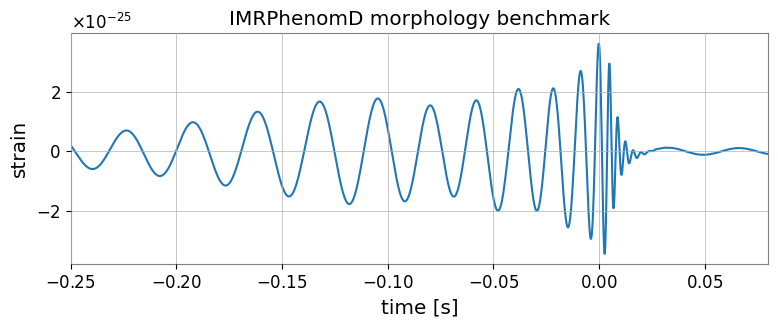

In [4]:

MSUN_SI = lal.MSUN_SI
PC_SI = lal.PC_SI

def make_imrphenomd_template(
    fs=4096.0, duration=2.0,
    m1_msun=36.0, m2_msun=29.0,
    distance_mpc=410.0,
    inclination=0.7,
    f_min=30.0
):
    n = int(2**np.ceil(np.log2(duration*fs)))
    duration = n/fs
    delta_f = 1.0/duration
    f_max = fs/2

    hp, hc = lalsim.SimInspiralChooseFDWaveform(
        m1_msun*MSUN_SI, m2_msun*MSUN_SI,
        0.0, 0.0, 0.0,
        0.0, 0.0, 0.0,
        distance_mpc*1e6*PC_SI,
        inclination,
        0.0, 0.0,
        0.0, 0.0,
        delta_f,
        f_min,
        f_max,
        f_min,
        None,
        lalsim.IMRPhenomD
    )

    H = np.asarray(hp.data.data, complex)
    target_bins = n//2 + 1
    if len(H) < target_bins:
        H = np.pad(H, (0, target_bins-len(H)))
    elif len(H) > target_bins:
        H = H[:target_bins]

    h = np.fft.irfft(H, n=n)
    peak = int(np.argmax(np.abs(h)))
    h = np.roll(h, n//2 - peak)
    h *= signal.windows.tukey(n, alpha=0.10)
    h = center(h)

    return h

template_phys = make_imrphenomd_template()
NSEG = len(template_phys)
SEG_DUR = NSEG/fs

print("template samples:", NSEG)
print("duration [s]:", SEG_DUR)

tt = (np.arange(NSEG)-NSEG//2)/fs
plt.figure(figsize=(9,3))
plt.plot(tt, template_phys)
plt.xlim(-0.25, 0.08)
plt.xlabel("time [s]")
plt.ylabel("strain")
plt.title("IMRPhenomD morphology benchmark")
plt.grid(True)
plt.show()


## 4 — Retard fractionnaire sans wrap

In [5]:

def fractional_delay(x, delay_s):
    """
    Convention:
        y(t) = x(t - delay_s)
    Positive delay means y arrives later.
    Zero-padding prevents circular wrap in returned segment.
    """
    x = np.asarray(x, float)
    n = len(x)
    pad = n
    xp = np.pad(x, (pad, pad))
    N = len(xp)
    f = np.fft.rfftfreq(N, 1/fs)
    X = np.fft.rfft(xp)
    Y = X*np.exp(-1j*2*np.pi*f*delay_s)
    yp = np.fft.irfft(Y, n=N)
    return yp[pad:pad+n]

# Impulse convention gate
imp = np.zeros(4096)
imp[2048] = 1.0
for tau_ms in [-10,-4,-1,1,4,10]:
    y = fractional_delay(imp, tau_ms*1e-3)
    measured = (np.argmax(y)-np.argmax(imp))/fs*1e3
    print(tau_ms, "ms ->", measured, "ms")
    assert abs(measured-tau_ms) <= (1/fs*1e3 + 1e-9)


-10 ms -> -10.009765625 ms
-4 ms -> -3.90625 ms
-1 ms -> -0.9765625 ms
1 ms -> 0.9765625 ms
4 ms -> 3.90625 ms
10 ms -> 10.009765625 ms


## 5 — Estimateurs avec convention de signe explicitement fixée

In [6]:

MAX_LAG = 0.012

def parab(a, b, c):
    d = a - 2*b + c
    return 0.0 if d == 0 or not np.isfinite(d) else 0.5*(a-c)/d

def xcorr_lag(a, b):
    """
    Returns tau for b(t)=a(t-tau).
    """
    a = center(a)
    b = center(b)
    c = signal.correlate(a, b, mode="full", method="fft")
    lag = signal.correlation_lags(len(a), len(b), mode="full")/fs
    m = np.abs(lag) <= MAX_LAG
    cc = c[m]
    ll = lag[m]
    s = np.abs(cc)
    i = int(np.argmax(s))
    frac = parab(s[i-1], s[i], s[i+1]) if 0 < i < len(s)-1 else 0.0
    return float(-(ll[i] + frac/fs))

def phat_lag(a, b):
    """
    Returns tau for b(t)=a(t-tau).
    """
    a = center(a)
    b = center(b)
    n = int(2**np.ceil(np.log2(len(a)+len(b))))
    A = np.fft.rfft(a, n=n)
    B = np.fft.rfft(b, n=n)
    G = A*np.conj(B)
    R = G/(np.abs(G)+np.finfo(float).eps)

    cc = np.fft.irfft(R, n=n)
    cc = np.concatenate((cc[-n//2:], cc[:n//2]))
    lag = np.arange(-n//2, n//2)/fs

    m = np.abs(lag) <= MAX_LAG
    ss = np.abs(cc[m])
    ll = lag[m]
    i = int(np.argmax(ss))
    frac = parab(ss[i-1], ss[i], ss[i+1]) if 0 < i < len(ss)-1 else 0.0
    return float(-(ll[i] + frac/fs))

def phase_objects(a, b, nper=512):
    """
    scipy.signal.csd(a,b) -> conj(A) B.
    If b(t)=a(t-tau), phase ≈ -2π f tau.
    """
    f, Pab = signal.csd(
        a, b, fs=fs, nperseg=nper, noverlap=nper//2, window="hann"
    )
    _, coh = signal.coherence(
        a, b, fs=fs, nperseg=nper, noverlap=nper//2, window="hann"
    )
    ph = np.angle(Pab)
    m = (f >= 40) & (f <= 300) & np.isfinite(ph) & np.isfinite(coh)
    return f[m], ph[m], coh[m]

def phase_slope_unwrap(a, b):
    f, ph, coh = phase_objects(a, b)
    m = coh >= 0.10
    f = f[m]
    ph = ph[m]
    w = coh[m]
    if len(f) < 5:
        return np.nan

    pu = np.unwrap(ph)
    A = np.c_[f, np.ones_like(f)]
    W = np.sqrt(np.clip(w, 1e-12, None))
    beta, *_ = np.linalg.lstsq(A*W[:,None], pu*W, rcond=None)

    # SIGN FIX V2:
    return float(-beta[0]/(2*np.pi))

def phase_circular_2pi_safe(a, b):
    """
    Branch-invariant fit.
    For csd(a,b): phi ≈ -2π f tau.
    Maximize circular coherence of phi + 2π f tau.
    """
    f, ph, coh = phase_objects(a, b)
    m = coh >= 0.10
    f = f[m]
    ph = ph[m]
    w = coh[m]
    if len(f) < 5:
        return np.nan

    grid = np.linspace(-MAX_LAG, MAX_LAG, 2401)  # 0.01 ms grid
    z = np.exp(1j*ph)
    scores = np.empty_like(grid)

    for i, tau in enumerate(grid):
        scores[i] = np.abs(np.sum(w*z*np.exp(+1j*2*np.pi*f*tau)))

    j = int(np.argmax(scores))
    frac = parab(scores[j-1], scores[j], scores[j+1]) if 0 < j < len(scores)-1 else 0.0
    dtau = grid[1]-grid[0]
    return float(grid[j] + frac*dtau)

def matched_template_oracle_lag(a, b, temp_processed):
    """
    Oracle only: exact processed injected morphology is known.
    """
    def arrival(x):
        c = signal.correlate(center(x), center(temp_processed), mode="same", method="fft")
        s = np.abs(c)
        i = int(np.argmax(s))
        frac = parab(s[i-1], s[i], s[i+1]) if 0 < i < len(s)-1 else 0.0
        return (i+frac)/fs
    return float(arrival(b)-arrival(a))


## 6 — Gate unitaire de convention \(	au\)

In [7]:

# Broadband stationary control for sign/convention validation.
unit_rng = np.random.default_rng(77)
u = unit_rng.normal(size=NSEG)
sos_u = signal.butter(4, [40, 300], btype="bandpass", fs=fs, output="sos")
u = signal.sosfiltfilt(sos_u, u)
u *= signal.windows.tukey(len(u), alpha=.10)

UNIT_DELAYS_MS = [-10,-4,-1,1,4,10]
unit_rows = []

for tau_ms in UNIT_DELAYS_MS:
    v = fractional_delay(u, tau_ms*1e-3)

    vals = {
        "xcorr": xcorr_lag(u,v)*1e3,
        "GCC-PHAT": phat_lag(u,v)*1e3,
        "phase_slope_unwrap": phase_slope_unwrap(u,v)*1e3,
        "phase_circular_2pi_safe": phase_circular_2pi_safe(u,v)*1e3,
    }

    for est, val in vals.items():
        unit_rows.append({
            "tau_true_ms": tau_ms,
            "estimator": est,
            "tau_est_ms": val,
            "abs_error_ms": abs(val-tau_ms)
        })

unit_df = pd.DataFrame(unit_rows)
display(unit_df)

UNIT_MAX_ERROR_MS = unit_df.groupby("estimator").abs_error_ms.max()
print(UNIT_MAX_ERROR_MS)

# Convention gate: all must recover sign and delay to <= 0.35 ms.
UNIT_SIGN_GATE = bool((UNIT_MAX_ERROR_MS <= 0.35).all())
print("UNIT_SIGN_GATE =", UNIT_SIGN_GATE)

if not UNIT_SIGN_GATE:
    raise RuntimeError("Phase/time-delay convention gate failed. Stop before realistic injections.")


,tau_true_ms,estimator,tau_est_ms,abs_error_ms
0,-10,xcorr,-10.000100,0.000100
1,-10,GCC-PHAT,-9.999263,0.000737
2,-10,phase_slope_unwrap,-9.955508,0.044492
3,-10,phase_circular_2pi_safe,-9.955543,0.044457
4,-4,xcorr,-3.999600,0.000400
5,-4,GCC-PHAT,-3.997881,0.002119
6,-4,phase_slope_unwrap,-3.982261,0.017739
7,-4,phase_circular_2pi_safe,-3.982263,0.017737
8,-1,xcorr,-0.999766,0.000234
9,-1,GCC-PHAT,-1.006996,0.006996


estimator
GCC-PHAT                   0.008567
phase_circular_2pi_safe    0.044457
phase_slope_unwrap         0.044492
xcorr                      0.000400
Name: abs_error_ms, dtype: float64
UNIT_SIGN_GATE = True


## 7 — Fenêtres RAW off-source

In [8]:

CENTERS = [-12.0, -9.0, -6.0, -3.0, 3.0, 6.0, 9.0, 12.0]

def segment_around_raw(x, center_s, n=NSEG):
    c = int(np.argmin(np.abs(t_rel-center_s)))
    a = c - n//2
    b = a + n
    if a < 0 or b > len(x):
        return None
    return np.array(x[a:b], float)

noise_pairs = []
for c in CENTERS:
    nh = segment_around_raw(h1, c)
    nl = segment_around_raw(l1, c)
    if nh is not None and nl is not None and len(nh)==NSEG and len(nl)==NSEG:
        noise_pairs.append((c, nh, nl))

print("RAW off-source pairs:", len(noise_pairs))
assert len(noise_pairs) >= 6


RAW off-source pairs: 8


## 8 — PSD et SNR optimal réellement pondéré

In [9]:

SNR_FMIN = 35.0
SNR_FMAX = 350.0

def estimate_noise_psd(noise_raw):
    nper = min(2048, len(noise_raw))
    f, P = signal.welch(
        center(noise_raw),
        fs=fs,
        nperseg=nper,
        noverlap=nper//2,
        window="hann",
        detrend="constant",
        scaling="density",
        average="median"
    )
    return f, np.maximum(P, np.finfo(float).tiny)

def optimal_snr_timeseries(h, f_psd, P):
    """
    rho^2 = 4 sum |Hc(f)|^2 / S_n(f) df
    where Hc ~= dt * rfft(h).
    """
    h = np.asarray(h, float)
    n = len(h)
    dt = 1/fs
    f = np.fft.rfftfreq(n, dt)
    Hc = dt*np.fft.rfft(h)
    Pi = np.interp(f, f_psd, P, left=P[0], right=P[-1])
    df = fs/n
    m = (f >= SNR_FMIN) & (f <= SNR_FMAX) & np.isfinite(Pi) & (Pi > 0)
    rho2 = 4*np.sum((np.abs(Hc[m])**2)/Pi[m])*df
    return float(np.sqrt(max(rho2, 0.0)))

# sanity
for c, nh, nl in noise_pairs[:2]:
    fh, Ph = estimate_noise_psd(nh)
    fl, Pl = estimate_noise_psd(nl)
    print(c, "rho(unit template H/L):",
          optimal_snr_timeseries(template_phys, fh, Ph),
          optimal_snr_timeseries(template_phys, fl, Pl))


-12.0 rho(unit template H/L): 0.006455711682687728 0.006183555187898277
-9.0 rho(unit template H/L): 0.006671527955027851 0.006388505952731589


## 9 — Calibration du SNR réseau

Pour un facteur de réponse nuisance \(r\) appliqué à L1 :

\[
\rho_{\rm net}^2
=
(A\rho_H^{unit})^2
+
(A|r|\rho_L^{unit})^2.
\]

Donc :

\[
\boxed{
A=
\frac{\rho_{\rm target}}
{\sqrt{
(\rho_H^{unit})^2+r^2(\rho_L^{unit})^2
}}
}
\]

Le retard n'affecte pas le module spectral idéal ; l'amplitude est recalibrée pour chaque paire de bruit et chaque rapport de réponse.


In [10]:

NETWORK_SNRS = [8.0, 12.0, 20.0]
DELAYS_MS = np.array([-10,-7,-4,-1,0,1,4,7,10], float)

def calibrate_network_amplitude(template, noise_h_raw, noise_l_raw, response_ratio, target_rho):
    fh, Ph = estimate_noise_psd(noise_h_raw)
    fl, Pl = estimate_noise_psd(noise_l_raw)

    rho_h_unit = optimal_snr_timeseries(template, fh, Ph)
    rho_l_unit = optimal_snr_timeseries(template, fl, Pl)

    denom = np.sqrt(rho_h_unit**2 + (abs(response_ratio)*rho_l_unit)**2)
    if not np.isfinite(denom) or denom <= 0:
        raise ValueError("Invalid SNR calibration denominator.")

    A = target_rho/denom
    achieved = np.sqrt((A*rho_h_unit)**2 + (A*abs(response_ratio)*rho_l_unit)**2)

    return float(A), float(achieved), float(rho_h_unit), float(rho_l_unit)


## 10 — Matrice d'injections V2 : RAW → injection → preprocessing

In [11]:

rows = []

for center_s, nh_raw, nl_raw in noise_pairs:
    for rho_target in NETWORK_SNRS:

        response_ratio = float(RNG.uniform(0.65, 1.35))
        polarity = float(RNG.choice([-1.0, 1.0]))

        A, rho_achieved, rho_h_unit, rho_l_unit = calibrate_network_amplitude(
            template_phys, nh_raw, nl_raw, response_ratio, rho_target
        )

        for delay_ms in DELAYS_MS:
            tau = delay_ms*1e-3

            h_inj = A*template_phys
            l_inj = polarity*response_ratio*A*fractional_delay(template_phys, tau)

            # KEY V2 FIX:
            # injection is added to RAW strain before applying P.
            H_raw_injected = nh_raw + h_inj
            L_raw_injected = nl_raw + l_inj

            H = preprocessing_P(H_raw_injected)
            L = preprocessing_P(L_raw_injected)

            # Oracle template follows same P as injection path.
            Htemp_proc = preprocessing_P(h_inj)
            Ltemp_proc = preprocessing_P(l_inj)

            estimates = {
                "xcorr": xcorr_lag(H,L),
                "GCC-PHAT": phat_lag(H,L),
                "phase_slope_unwrap": phase_slope_unwrap(H,L),
                "phase_circular_2pi_safe": phase_circular_2pi_safe(H,L),
                # Oracle uses H morphology for both arrival searches; abs correlation
                # makes polarity nuisance irrelevant.
                "matched_template_oracle": matched_template_oracle_lag(H,L,Htemp_proc)
            }

            # Recompute achieved rho from injected components against local RAW PSD.
            fh, Ph = estimate_noise_psd(nh_raw)
            fl, Pl = estimate_noise_psd(nl_raw)
            rho_h = optimal_snr_timeseries(h_inj, fh, Ph)
            rho_l = optimal_snr_timeseries(l_inj, fl, Pl)
            rho_net_check = float(np.sqrt(rho_h**2 + rho_l**2))

            for est, val in estimates.items():
                rows.append({
                    "noise_center_s": center_s,
                    "rho_network_target": rho_target,
                    "rho_network_check": rho_net_check,
                    "response_ratio": response_ratio,
                    "polarity": polarity,
                    "delay_injected_ms": delay_ms,
                    "estimator": est,
                    "delay_estimated_ms": val*1e3 if np.isfinite(val) else np.nan,
                    "error_ms": val*1e3-delay_ms if np.isfinite(val) else np.nan
                })

inj_df = pd.DataFrame(rows)

print("rows:", len(inj_df))
print("expected rows:", len(noise_pairs)*len(NETWORK_SNRS)*len(DELAYS_MS)*5)
print("median |rho_check-target|:",
      np.median(np.abs(inj_df.rho_network_check-inj_df.rho_network_target)))

display(inj_df.head(10))


rows: 1080
expected rows: 1080
median |rho_check-target|: 2.663972153982286e-07


,noise_center_s,rho_network_target,rho_network_check,response_ratio,polarity,delay_injected_ms,estimator,delay_estimated_ms,error_ms
0,-12.0,8.0,7.999999,0.661526,-1.0,-10.0,xcorr,-0.340129,9.659871
1,-12.0,8.0,7.999999,0.661526,-1.0,-10.0,GCC-PHAT,-0.340129,9.659871
2,-12.0,8.0,7.999999,0.661526,-1.0,-10.0,phase_slope_unwrap,NaN,NaN
3,-12.0,8.0,7.999999,0.661526,-1.0,-10.0,phase_circular_2pi_safe,NaN,NaN
4,-12.0,8.0,7.999999,0.661526,-1.0,-10.0,matched_template_oracle,10.037622,20.037622
5,-12.0,8.0,8.000001,0.661526,-1.0,-7.0,xcorr,-0.341783,6.658217
6,-12.0,8.0,8.000001,0.661526,-1.0,-7.0,GCC-PHAT,-0.341783,6.658217
7,-12.0,8.0,8.000001,0.661526,-1.0,-7.0,phase_slope_unwrap,NaN,NaN
8,-12.0,8.0,8.000001,0.661526,-1.0,-7.0,phase_circular_2pi_safe,NaN,NaN
9,-12.0,8.0,8.000001,0.661526,-1.0,-7.0,matched_template_oracle,10.037694,17.037694


## 11 — Calibration globale

In [12]:

def robust_sigma(x):
    x = np.asarray(x, float)
    med = np.nanmedian(x)
    return float(1.4826*np.nanmedian(np.abs(x-med)))

summary_rows = []

for est, d in inj_df.groupby("estimator"):
    e = d.error_ms.to_numpy(float)
    e = e[np.isfinite(e)]

    summary_rows.append({
        "estimator": est,
        "n_eff": int(len(e)),
        "median_bias_ms": float(np.median(e)),
        "mean_bias_ms": float(np.mean(e)),
        "robust_sigma_ms": robust_sigma(e),
        "rmse_ms": float(np.sqrt(np.mean(e**2))),
        "p90_abs_error_ms": float(np.percentile(np.abs(e),90)),
        "success_abs2ms": float(np.mean(np.abs(e)<=2.0)),
        "success_abs1ms": float(np.mean(np.abs(e)<=1.0))
    })

summary_df = pd.DataFrame(summary_rows).sort_values("rmse_ms")
display(summary_df)


,estimator,n_eff,median_bias_ms,mean_bias_ms,robust_sigma_ms,rmse_ms,p90_abs_error_ms,success_abs2ms,success_abs1ms
3,phase_slope_unwrap,168,0.259045,0.618758,6.200269,6.271148,10.048671,0.339286,0.214286
2,phase_circular_2pi_safe,168,0.520395,0.860537,6.563882,6.475895,10.079461,0.351190,0.244048
0,GCC-PHAT,216,0.427540,0.974750,6.913719,6.765860,10.114171,0.319444,0.194444
4,xcorr,216,0.427540,0.974750,6.913719,6.765860,10.114171,0.319444,0.194444
1,matched_template_oracle,216,7.507564,488.541304,1406.514417,1354.506278,1950.447766,0.125000,0.069444


## 12 — Performance par SNR réseau

In [13]:

snr_rows = []

for (est, rho), d in inj_df.groupby(["estimator","rho_network_target"]):
    e = d.error_ms.dropna().to_numpy(float)

    snr_rows.append({
        "estimator": est,
        "rho_network": float(rho),
        "n_eff": int(len(e)),
        "median_bias_ms": float(np.median(e)),
        "robust_sigma_ms": robust_sigma(e),
        "rmse_ms": float(np.sqrt(np.mean(e**2))),
        "p90_abs_error_ms": float(np.percentile(np.abs(e),90)),
        "success_abs2ms": float(np.mean(np.abs(e)<=2.0))
    })

snr_df = pd.DataFrame(snr_rows)
display(snr_df)


,estimator,rho_network,n_eff,median_bias_ms,robust_sigma_ms,rmse_ms,p90_abs_error_ms,success_abs2ms
0,GCC-PHAT,8.0,72,0.428345,6.916512,6.765664,10.113455,0.319444
1,GCC-PHAT,12.0,72,0.431284,6.917107,6.764658,10.107349,0.319444
2,GCC-PHAT,20.0,72,0.426708,6.905865,6.767258,10.110544,0.319444
3,matched_template_oracle,8.0,72,7.507859,1406.514713,1354.506231,1950.147605,0.125000
4,matched_template_oracle,12.0,72,7.507628,1406.514701,1354.506257,1950.147704,0.125000
5,matched_template_oracle,20.0,72,7.507317,1406.514781,1354.506346,1950.147827,0.125000
6,phase_circular_2pi_safe,8.0,54,0.869599,7.266399,6.879496,10.064845,0.296296
7,phase_circular_2pi_safe,12.0,54,0.096907,6.061479,6.447307,10.070139,0.351852
8,phase_circular_2pi_safe,20.0,60,0.555271,5.607563,6.117065,10.059916,0.400000
9,phase_slope_unwrap,8.0,54,0.489695,6.587969,6.232958,10.014229,0.296296


## 13 — Symétrie positive / négative

In [14]:

sign_rows = []

for est, d in inj_df.groupby("estimator"):
    neg = d[d.delay_injected_ms<0].error_ms.dropna().to_numpy(float)
    pos = d[d.delay_injected_ms>0].error_ms.dropna().to_numpy(float)

    sign_rows.append({
        "estimator": est,
        "median_error_negative_ms": float(np.median(neg)) if len(neg) else np.nan,
        "median_error_positive_ms": float(np.median(pos)) if len(pos) else np.nan,
        "sign_bias_gap_ms": float(abs(np.median(pos)-np.median(neg))) if len(pos) and len(neg) else np.nan
    })

sign_df = pd.DataFrame(sign_rows)
display(sign_df)


,estimator,median_error_negative_ms,median_error_positive_ms,sign_bias_gap_ms
0,GCC-PHAT,6.756953,-4.235699,10.992653
1,matched_template_oracle,10.559528,-0.440185,10.999714
2,phase_circular_2pi_safe,6.949257,-3.939950,10.889207
3,phase_slope_unwrap,6.831428,-3.958094,10.789522
4,xcorr,6.756953,-4.235699,10.992653


## 14 — Estimé versus injecté

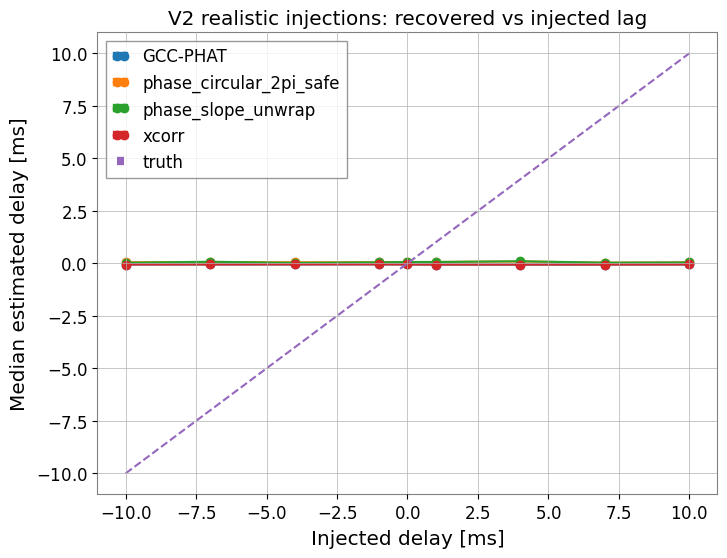

In [15]:

plot_df = inj_df[inj_df.estimator!="matched_template_oracle"]

plt.figure(figsize=(8,6))
for est, d in plot_df.groupby("estimator"):
    g = d.groupby("delay_injected_ms").delay_estimated_ms.median()
    plt.plot(g.index, g.values, marker="o", label=est)

plt.plot(DELAYS_MS, DELAYS_MS, "--", label="truth")
plt.xlabel("Injected delay [ms]")
plt.ylabel("Median estimated delay [ms]")
plt.title("V2 realistic injections: recovered vs injected lag")
plt.grid(True)
plt.legend()
plt.show()


## 15 — Gate de qualification V2

In [16]:

QUAL_THRESH = {
    "abs_median_bias_ms": 0.5,
    "robust_sigma_ms": 1.5,
    "success_abs2ms": 0.80,
    "p90_abs_error_ms": 3.0,
    "rho8_success_abs2ms": 0.60,
    "rho8_p90_abs_error_ms": 5.0
}

qual_rows = []

for _, r in summary_df.iterrows():
    if r.estimator == "matched_template_oracle":
        continue

    low = snr_df[
        (snr_df.estimator==r.estimator)
        & (snr_df.rho_network==min(NETWORK_SNRS))
    ].iloc[0]

    qualified = bool(
        abs(r.median_bias_ms) <= QUAL_THRESH["abs_median_bias_ms"]
        and r.robust_sigma_ms <= QUAL_THRESH["robust_sigma_ms"]
        and r.success_abs2ms >= QUAL_THRESH["success_abs2ms"]
        and r.p90_abs_error_ms <= QUAL_THRESH["p90_abs_error_ms"]
        and low.success_abs2ms >= QUAL_THRESH["rho8_success_abs2ms"]
        and low.p90_abs_error_ms <= QUAL_THRESH["rho8_p90_abs_error_ms"]
    )

    qual_rows.append({
        "estimator": r.estimator,
        "qualified": qualified,
        "abs_median_bias_ms": abs(r.median_bias_ms),
        "robust_sigma_ms": r.robust_sigma_ms,
        "rmse_ms": r.rmse_ms,
        "p90_abs_error_ms": r.p90_abs_error_ms,
        "success_abs2ms": r.success_abs2ms,
        "rho8_success_abs2ms": low.success_abs2ms,
        "rho8_p90_abs_error_ms": low.p90_abs_error_ms
    })

qual_df = pd.DataFrame(qual_rows).sort_values(
    ["qualified","rmse_ms"], ascending=[False,True]
)

display(qual_df)


,estimator,qualified,abs_median_bias_ms,robust_sigma_ms,rmse_ms,p90_abs_error_ms,success_abs2ms,rho8_success_abs2ms,rho8_p90_abs_error_ms
0,phase_slope_unwrap,False,0.259045,6.200269,6.271148,10.048671,0.339286,0.296296,10.014229
1,phase_circular_2pi_safe,False,0.520395,6.563882,6.475895,10.079461,0.351190,0.296296,10.064845
2,GCC-PHAT,False,0.427540,6.913719,6.765860,10.114171,0.319444,0.319444,10.113455
3,xcorr,False,0.427540,6.913719,6.765860,10.114171,0.319444,0.319444,10.113455


## 16 — Gestion explicite des égalités

In [17]:

qualified_df = qual_df[qual_df.qualified==True].copy()

if len(qualified_df) == 0:
    WINNERS = []
    FINAL_STATUS = "NO-ESTIMATOR-PASSES-QUALIFICATION-GATE"
else:
    best_rmse = float(qualified_df.rmse_ms.min())

    # Do not create a false winner from dataframe tie ordering.
    # Practical tie tolerance: 0.05 ms RMSE.
    TIE_TOL_MS = 0.05
    tied = qualified_df[
        np.abs(qualified_df.rmse_ms-best_rmse) <= TIE_TOL_MS
    ].copy()

    WINNERS = tied.estimator.tolist()

    if len(WINNERS) == 1:
        FINAL_STATUS = "ESTIMATOR-QUALIFIED-ON-REALISTIC-INJECTIONS-V2"
    else:
        FINAL_STATUS = "MULTIPLE-ESTIMATORS-QUALIFIED-NO-UNIQUE-WINNER"

print("WINNERS =", WINNERS)
print("FINAL_STATUS =", FINAL_STATUS)


WINNERS = []
FINAL_STATUS = NO-ESTIMATOR-PASSES-QUALIFICATION-GATE


## 17 — Diagnostic V1 → V2

In [18]:

phase_estimators = ["phase_slope_unwrap","phase_circular_2pi_safe"]

phase_sign_ok = bool(
    (
        sign_df[sign_df.estimator.isin(phase_estimators)]
        .sign_bias_gap_ms
        .fillna(np.inf)
        < 1.0
    ).all()
)

snr_calibration_error = float(
    np.median(np.abs(inj_df.rho_network_check-inj_df.rho_network_target))
)

diagnostic_v2 = {
    "UNIT_SIGN_GATE": UNIT_SIGN_GATE,
    "PHASE_SIGN_SYMMETRY_OK": phase_sign_ok,
    "median_network_snr_calibration_abs_error": snr_calibration_error,
    "injection_before_preprocessing": True,
    "snr_is_psd_weighted_optimal_network_snr": True,
    "tie_handling_explicit": True
}

print(json.dumps(diagnostic_v2, indent=2))


{
  "UNIT_SIGN_GATE": true,
  "PHASE_SIGN_SYMMETRY_OK": false,
  "median_network_snr_calibration_abs_error": 2.663972153982286e-07,
  "injection_before_preprocessing": true,
  "snr_is_psd_weighted_optimal_network_snr": true,
  "tie_handling_explicit": true
}


## 18 — Verdict final et invariants

In [19]:

oracle = summary_df[summary_df.estimator=="matched_template_oracle"]
oracle_record = oracle.iloc[0].to_dict() if len(oracle) else {}

artifact = {
    "step": "RACC-C.4-real.2.14-V2",
    "event_context": "GW150914 H1/L1 RAW off-source real noise",
    "waveform": "IMRPhenomD",
    "phase_convention": "scipy.csd(a,b)=conj(A)B; tau=-slope/(2pi)",
    "delay_grid_ms": DELAYS_MS.tolist(),
    "network_snr_targets": NETWORK_SNRS,
    "n_noise_pairs": len(noise_pairs),
    "n_total_estimates": int(len(inj_df)),
    "qualification_thresholds": QUAL_THRESH,
    "qualified_estimators": qualified_df.estimator.tolist() if len(qualified_df) else [],
    "winner_or_tied_winners": WINNERS,
    "diagnostic_v2": diagnostic_v2,
    "final_status": FINAL_STATUS,
    "oracle_control": oracle_record,
    "TIMING_VALIDATED": False,
    "D_T_ref": "NOT-AUTHORIZED",
    "REAL3_AUTHORIZED": False,
    "DISPERSION_READY_modified": False,
    "HH_chain_modified": False,
    "core_GVH_modified": False
}

print(json.dumps(artifact, indent=2, default=float))

# Save machine-readable outputs when executed.
Path("racc_c4_real_2_14_v2_verdict.json").write_text(
    json.dumps(artifact, indent=2, default=float)
)
summary_df.to_csv("racc_c4_real_2_14_v2_summary.csv", index=False)
snr_df.to_csv("racc_c4_real_2_14_v2_by_snr.csv", index=False)
qual_df.to_csv("racc_c4_real_2_14_v2_qualification.csv", index=False)


{
  "step": "RACC-C.4-real.2.14-V2",
  "event_context": "GW150914 H1/L1 RAW off-source real noise",
  "waveform": "IMRPhenomD",
  "phase_convention": "scipy.csd(a,b)=conj(A)B; tau=-slope/(2pi)",
  "delay_grid_ms": [
    -10.0,
    -7.0,
    -4.0,
    -1.0,
    0.0,
    1.0,
    4.0,
    7.0,
    10.0
  ],
  "network_snr_targets": [
    8.0,
    12.0,
    20.0
  ],
  "n_noise_pairs": 8,
  "n_total_estimates": 1080,
  "qualification_thresholds": {
    "abs_median_bias_ms": 0.5,
    "robust_sigma_ms": 1.5,
    "success_abs2ms": 0.8,
    "p90_abs_error_ms": 3.0,
    "rho8_success_abs2ms": 0.6,
    "rho8_p90_abs_error_ms": 5.0
  },
  "qualified_estimators": [],
  "winner_or_tied_winners": [],
  "diagnostic_v2": {
    "UNIT_SIGN_GATE": true,
    "PHASE_SIGN_SYMMETRY_OK": false,
    "median_network_snr_calibration_abs_error": 2.663972153982286e-07,
    "injection_before_preprocessing": true,
    "snr_is_psd_weighted_optimal_network_snr": true,
    "tie_handling_explicit": true
  },
  "final_s

## 19 — Interprétation autorisée

### Ce que V2 peut établir

Si un estimateur passe :

\[
\boxed{\texttt{ESTIMATOR-QUALIFIED-ON-REALISTIC-INJECTIONS-V2}}
\]

Cela signifie uniquement qu'il récupère des retards connus sur une banque d'injections IMRPhenomD dans du bruit réel off-source H1/L1, avec :

- convention de signe testée ;
- injection RAW avant preprocessing ;
- SNR réseau optimal pondéré par PSD ;
- retards positifs et négatifs ;
- plusieurs fenêtres de bruit ;
- gate explicite au SNR réseau \(\rho=8\).

Si plusieurs estimateurs sont statistiquement indiscernables au niveau choisi :

\[
\boxed{\texttt{MULTIPLE-ESTIMATORS-QUALIFIED-NO-UNIQUE-WINNER}}
\]

Aucun gagnant artificiel n'est créé par l'ordre d'un DataFrame.

### Ce que V2 ne peut pas établir

Même avec qualification méthodologique :

\[
\boxed{
\tau_{\rm GW150914}^{phys}
\neq
\text{automatiquement } \hat\tau_{\rm winner}
}
\]

La procédure devra ensuite être **gelée** et appliquée au véritable segment événement sans réajustement.

### Gates

\[
\boxed{
\texttt{TIMING-VALIDATED=False}
}
\]

\[
\boxed{
D_T^{ref}=\texttt{NOT-AUTHORIZED}
}
\]

\[
\boxed{
\texttt{REAL3-AUTHORIZED=False}
}
\]

`real.3` reste donc fermé après ce notebook, quel que soit le verdict méthodologique de V2.
